# TQQQ EMA5 / EMA30 金叉死叉回测

策略规则：

- 标的：`TQQQ`
- 数据：Yahoo Finance 日线复权价格，起始日期 `2015-01-01`，结束到今天
- 买入：EMA5 上穿 EMA30
- 卖出：EMA5 下穿 EMA30
- 执行假设：当天收盘后产生信号，下一交易日开盘买入或卖出，持仓期间按收盘价估值
- 仓位：满仓或空仓，不加杠杆，不计滑点
- 手续费：每次买入/卖出固定扣除 `$0.99`


In [28]:
# 如果 notebook 环境缺依赖，先运行下面这行：
# %pip install -q yfinance pandas matplotlib

from datetime import date

import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [62]:
SYMBOL = "TQQQ"
START_DATE = "2015-01-01"
END_DATE = date.today().isoformat()
INITIAL_CAPITAL = 10_000
COMMISSION_PER_TRADE = 0.99

# EMA 参数。short_window 上穿 long_window 买入；下穿卖出。
SHORT_WINDOW = 5
LONG_WINDOW = 30

raw = yf.download(
    SYMBOL,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
)

if raw.empty:
    raise RuntimeError("没有下载到行情数据，请检查网络、yfinance 或标的代码。")

df = raw.copy()
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.rename(columns=str.lower)
df = df[["open", "high", "low", "close", "volume"]].dropna()
df.tail()


Price,open,high,low,close,volume
Date,,,,,
2026-04-08,48.6400,48.9200,47.1500,48.0000,102015100
2026-04-09,48.0200,49.0900,47.3100,48.9600,78953600
2026-04-10,49.3600,49.8100,48.8200,49.1700,65481600
2026-04-13,48.7800,50.7400,48.4600,50.6600,67169100
2026-04-14,51.3900,53.4300,51.3800,53.4100,71262800


## 生成 EMA 信号和 next-open 回测

`signal` 是收盘后看到的趋势信号；`target_position` 是下一交易日目标仓位。

本版本按更贴近实盘的方式执行：第 t 日收盘确认金叉/死叉，第 t+1 日开盘价买入或卖出；持仓期间每天用收盘价估值。


In [63]:
bt = df.copy()
bt["ema_short"] = bt["close"].ewm(span=SHORT_WINDOW, adjust=False).mean()
bt["ema_long"] = bt["close"].ewm(span=LONG_WINDOW, adjust=False).mean()

# 短均线在长均线上方时持有；否则空仓。
bt["signal"] = (bt["ema_short"] > bt["ema_long"]).astype(int)

# 第 t 日收盘看到信号，第 t+1 日开盘执行，所以目标仓位 shift(1)。
bt["target_position"] = bt["signal"].shift(1).fillna(0).astype(int)
bt["trade_signal"] = bt["target_position"].diff().fillna(bt["target_position"]).astype(int)

# next-open 资金模拟：买卖按当天 open 成交；当天资产用 close 估值。
cash = INITIAL_CAPITAL
shares = 0.0
equity_values = []
position_values = []
commission_values = []
trade_price_values = []

for row in bt.itertuples():
    open_price = float(row.open)
    close_price = float(row.close)
    trade_signal = int(row.trade_signal)
    commission = 0.0
    trade_price = None

    if trade_signal == 1 and shares == 0:
        commission = COMMISSION_PER_TRADE
        investable_cash = max(cash - commission, 0)
        shares = investable_cash / open_price
        cash = 0.0
        trade_price = open_price
    elif trade_signal == -1 and shares > 0:
        commission = COMMISSION_PER_TRADE
        cash = shares * open_price - commission
        shares = 0.0
        trade_price = open_price

    equity_values.append(cash + shares * close_price)
    position_values.append(1 if shares > 0 else 0)
    commission_values.append(commission)
    trade_price_values.append(trade_price)

bt["position"] = position_values
bt["commission"] = commission_values
bt["trade_price"] = trade_price_values
bt["strategy_equity"] = equity_values
bt["buy_hold_equity"] = INITIAL_CAPITAL * (bt["close"] / bt["close"].iloc[0])
bt["daily_return"] = bt["close"].pct_change().fillna(0)
bt["strategy_return"] = bt["strategy_equity"].pct_change().fillna(0)

bt[["open", "close", "ema_short", "ema_long", "signal", "target_position", "position", "trade_signal", "trade_price", "commission", "strategy_equity", "buy_hold_equity"]].tail()


Price,open,close,ema_short,ema_long,signal,target_position,position,trade_signal,trade_price,commission,strategy_equity,buy_hold_equity
Date,,,,,,,,,,,,
2026-04-08,48.6400,48.0000,44.8597,45.6265,0,0,0,0,NaN,0.0000,"154,054.4720","250,126.2791"
2026-04-09,48.0200,48.9600,46.2265,45.8416,1,0,0,0,NaN,0.0000,"154,054.4720","255,128.7999"
2026-04-10,49.3600,49.1700,47.2077,46.0563,1,1,1,1,49.3600,0.9900,"153,460.4808","256,223.0976"
2026-04-13,48.7800,50.6600,48.3584,46.3533,1,1,1,0,NaN,0.0000,"158,110.8039","263,987.4429"
2026-04-14,51.3900,53.4100,50.0423,46.8086,1,1,1,0,NaN,0.0000,"166,693.6051","278,317.5943"


## 统计结果

In [64]:
def max_drawdown(equity: pd.Series) -> float:
    peak = equity.cummax()
    drawdown = equity / peak - 1
    return drawdown.min()


def annualized_return(equity: pd.Series) -> float:
    days = (equity.index[-1] - equity.index[0]).days
    years = days / 365.25
    return (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1


def annualized_volatility(returns: pd.Series) -> float:
    return returns.std() * (252 ** 0.5)


strategy_total_return = bt["strategy_equity"].iloc[-1] / INITIAL_CAPITAL - 1
buy_hold_total_return = bt["buy_hold_equity"].iloc[-1] / INITIAL_CAPITAL - 1
total_commission = bt["commission"].sum()

# closed_trades 会在后面的交易统计单元格生成；这里先只统计资金曲线指标。
summary = pd.DataFrame(
    {
        "最终资产": [bt["strategy_equity"].iloc[-1], bt["buy_hold_equity"].iloc[-1]],
        "总收益率": [strategy_total_return, buy_hold_total_return],
        "年化收益率": [annualized_return(bt["strategy_equity"]), annualized_return(bt["buy_hold_equity"])],
        "最大回撤": [max_drawdown(bt["strategy_equity"]), max_drawdown(bt["buy_hold_equity"])],
        "年化波动率": [annualized_volatility(bt["strategy_return"]), annualized_volatility(bt["daily_return"])],
        "手续费合计": [total_commission, 0.0],
    },
    index=["EMA5/EMA30 策略", "买入持有 TQQQ"],
)

summary_display = summary.copy()
summary_display["最终资产"] = summary_display["最终资产"].map(lambda x: f"${x:,.2f}")
summary_display["手续费合计"] = summary_display["手续费合计"].map(lambda x: f"${x:,.2f}")
for col in ["总收益率", "年化收益率", "最大回撤", "年化波动率"]:
    summary_display[col] = summary_display[col].map(lambda x: f"{x:.2%}")

summary_display


,最终资产,总收益率,年化收益率,最大回撤,年化波动率,手续费合计
EMA5/EMA30 策略,"$166,693.61",1566.94%,28.33%,-56.93%,38.62%,$119.79
买入持有 TQQQ,"$278,317.59",2683.18%,34.30%,-81.66%,64.82%,$0.00


## 交易记录

`trade_date` 是实际仓位变化日，也就是信号产生后的下一交易日。

In [65]:
trades = bt.loc[bt["trade_signal"] != 0, ["open", "close", "trade_price", "ema_short", "ema_long", "trade_signal", "commission", "strategy_equity"]].copy()
trades["action"] = trades["trade_signal"].map({1: "BUY", -1: "SELL"})
trades = trades.rename_axis("trade_date").reset_index()
trades = trades[["trade_date", "action", "trade_price", "open", "close", "ema_short", "ema_long", "commission", "strategy_equity"]]
trades.tail(20)


Price,trade_date,action,trade_price,open,close,ema_short,ema_long,commission,strategy_equity
101,2024-09-04,SELL,30.0222,30.0222,30.4058,31.8131,32.7942,0.9900,"112,489.7981"
102,2024-09-17,BUY,33.2979,33.2979,32.7027,32.3242,32.1679,0.9900,"110,478.3006"
103,2024-11-05,SELL,35.0087,35.0087,35.9907,35.5960,35.6066,0.9900,"118,267.5673"
104,2024-11-07,BUY,39.5532,39.5532,40.7325,38.0450,36.1368,0.9900,"121,792.7379"
105,2025-01-02,SELL,39.8728,39.8728,38.9272,40.2548,40.9659,0.9900,"119,221.0960"
106,2025-01-22,BUY,42.9917,42.9917,43.4670,41.4625,40.5902,0.9900,"120,538.0713"
107,2025-02-04,SELL,40.0559,40.0559,41.4124,40.9236,40.8288,0.9900,"111,077.9949"
108,2025-02-05,BUY,40.7688,40.7688,41.9520,41.2664,40.9013,0.9900,"114,300.7326"
109,2025-02-26,SELL,38.9024,38.9024,38.6747,40.1591,41.5296,0.9900,"105,990.9091"
110,2025-05-02,BUY,29.1164,29.1164,29.5087,27.8586,27.0646,0.9900,"107,417.8204"


In [66]:
# 展示所有交易信号，不截断。
# trade_date 是实际成交日；trade_price 是下一交易日开盘成交价。
all_trades = trades.copy()
all_trades["trade_date"] = pd.to_datetime(all_trades["trade_date"]).dt.date
all_trades = all_trades.rename(
    columns={
        "trade_date": "成交日期",
        "action": "动作",
        "trade_price": "成交开盘价",
        "open": "当日开盘价",
        "close": "当日收盘估值价",
        "ema_short": f"EMA{SHORT_WINDOW}",
        "ema_long": f"EMA{LONG_WINDOW}",
        "commission": "手续费",
        "strategy_equity": "交易日收盘资产",
    }
)

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 220):
    display(all_trades)


Price,成交日期,动作,成交开盘价,当日开盘价,当日收盘估值价,EMA5,EMA30,手续费,交易日收盘资产
0,2015-01-26,BUY,1.9736,1.9736,1.9752,1.9315,1.8876,0.9900,"10,007.0592"
1,2015-01-29,SELL,1.7848,1.7848,1.8428,1.8545,1.8752,0.9900,"9,041.3726"
2,2015-02-06,BUY,1.9518,1.9518,1.9081,1.8994,1.8789,0.9900,"8,838.0525"
3,2015-03-13,SELL,2.0433,2.0433,2.0223,2.0613,2.0820,0.9900,"9,463.3620"
4,2015-03-18,BUY,2.0934,2.0934,2.1722,2.1151,2.0906,0.9900,"9,818.6828"
5,2015-03-27,SELL,2.0137,2.0137,2.0372,2.0758,2.1009,0.9900,"9,101.4914"
6,2015-04-10,BUY,2.1404,2.1404,2.1664,2.1164,2.0933,0.9900,"9,211.1035"
7,2015-05-07,SELL,2.0912,2.0912,2.1293,2.1547,2.1656,0.9900,"8,890.1282"
8,2015-05-11,BUY,2.2135,2.2135,2.1831,2.1759,2.1693,0.9900,"8,767.1283"
9,2015-05-14,SELL,2.2203,2.2203,2.2620,2.1993,2.1742,0.9900,"8,915.2540"


In [67]:
completed = []
entry = None

for row in trades.itertuples(index=False):
    if row.action == "BUY":
        entry = row
    elif row.action == "SELL" and entry is not None:
        gross_return = row.trade_price / entry.trade_price - 1
        net_return = row.strategy_equity / entry.strategy_equity - 1
        completed.append(
            {
                "entry_date": entry.trade_date,
                "entry_price": entry.trade_price,
                "entry_equity_after_fee": entry.strategy_equity,
                "exit_date": row.trade_date,
                "exit_price": row.trade_price,
                "exit_equity_after_fee": row.strategy_equity,
                "gross_return": gross_return,
                "net_return_after_fee": net_return,
                "commission": float(entry.commission) + float(row.commission),
            }
        )
        entry = None

closed_trades = pd.DataFrame(completed)
win_rate = None
if not closed_trades.empty:
    win_rate = (closed_trades["net_return_after_fee"] > 0).mean()
    trade_stats = pd.DataFrame(
        {
            "完整交易回合数": [len(closed_trades)],
            "盈利回合数": [int((closed_trades["net_return_after_fee"] > 0).sum())],
            "胜率": [f"{win_rate:.2%}"],
            "手续费合计": [f"${bt['commission'].sum():,.2f}"],
            "平均单笔净收益": [f"{closed_trades['net_return_after_fee'].mean():.2%}"],
        }
    )
    display(trade_stats)

    closed_trades_display = closed_trades.tail(20).copy()
    for col in ["entry_price", "exit_price", "entry_equity_after_fee", "exit_equity_after_fee", "commission"]:
        closed_trades_display[col] = closed_trades_display[col].map(lambda x: f"${x:,.2f}")
    closed_trades_display["gross_return"] = closed_trades_display["gross_return"].map(lambda x: f"{x:.2%}")
    closed_trades_display["net_return_after_fee"] = closed_trades_display["net_return_after_fee"].map(lambda x: f"{x:.2%}")
    display(closed_trades_display)
else:
    print("还没有完整买卖闭环。")

if entry is not None:
    latest_price = bt["close"].iloc[-1]
    latest_equity = bt["strategy_equity"].iloc[-1]
    print(f"当前仍持仓：入场日 {entry.trade_date.date()}，入场开盘价 ${entry.trade_price:,.2f}，最新收盘价 ${latest_price:,.2f}，当前策略资产 ${latest_equity:,.2f}")


,完整交易回合数,盈利回合数,胜率,手续费合计,平均单笔净收益
0,60,24,40.00%,$119.79,6.25%


,entry_date,entry_price,entry_equity_after_fee,exit_date,exit_price,exit_equity_after_fee,gross_return,net_return_after_fee,commission
40,2022-11-15,$11.29,"$56,327.28",2022-12-08,$9.97,"$51,198.96",-11.75%,-9.10%,$1.98
41,2022-12-14,$10.61,"$50,252.84",2022-12-16,$9.30,"$44,903.84",-12.29%,-10.64%,$1.98
42,2023-01-17,$9.63,"$45,238.61",2023-02-27,$10.79,"$50,318.85",12.06%,11.23%,$1.98
43,2023-03-07,$11.31,"$48,438.42",2023-03-10,$10.47,"$46,600.70",-7.39%,-3.79%,$1.98
44,2023-03-17,$11.97,"$45,926.79",2023-08-10,$19.69,"$76,686.43",64.57%,66.98%,$1.98
45,2023-08-31,$20.36,"$77,415.08",2023-09-19,$19.09,"$71,887.05",-6.26%,-7.14%,$1.98
46,2023-10-12,$19.19,"$70,811.50",2023-10-19,$18.06,"$67,659.68",-5.88%,-4.45%,$1.98
47,2023-11-07,$18.64,"$68,946.60",2024-04-11,$29.21,"$106,008.34",56.68%,53.75%,$1.98
48,2024-04-12,$29.34,"$103,953.76",2024-04-15,$29.50,"$106,572.86",0.53%,2.52%,$1.98
49,2024-05-08,$28.17,"$108,332.62",2024-07-24,$34.54,"$130,662.81",22.61%,20.61%,$1.98


当前仍持仓：入场日 2026-04-10，入场开盘价 $49.36，最新收盘价 $53.41，当前策略资产 $166,693.61


## 类似视频里的交易收益表

`total_fund` 是每个完整卖出回合后的账户总资产；`return_percentage` 是这一完整买卖回合扣除手续费后的收益率百分比。


In [68]:
if closed_trades.empty:
    print("还没有完整买卖闭环。")
else:
    video_like_table = closed_trades.copy()
    video_like_table["trade_no"] = range(len(video_like_table))
    video_like_table["total_fund"] = video_like_table["exit_equity_after_fee"]
    video_like_table["return_percentage"] = video_like_table["net_return_after_fee"] * 100
    video_like_table = video_like_table[
        [
            "trade_no",
            "entry_date",
            "entry_price",
            "exit_date",
            "exit_price",
            "total_fund",
            "return_percentage",
            "commission",
        ]
    ]

    video_like_display = video_like_table.copy()
    video_like_display["entry_date"] = pd.to_datetime(video_like_display["entry_date"]).dt.date
    video_like_display["exit_date"] = pd.to_datetime(video_like_display["exit_date"]).dt.date
    for col in ["entry_price", "exit_price", "total_fund", "commission"]:
        video_like_display[col] = video_like_display[col].map(lambda x: round(float(x), 2))
    video_like_display["return_percentage"] = video_like_display["return_percentage"].map(lambda x: round(float(x), 2))

    print(f"Lose: {(video_like_table['return_percentage'] <= 0).sum()}  Win: {(video_like_table['return_percentage'] > 0).sum()}")
    with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 240):
        display(video_like_display)


Lose: 36  Win: 24


,trade_no,entry_date,entry_price,exit_date,exit_price,total_fund,return_percentage,commission
0,0,2015-01-26,1.9700,2015-01-29,1.7800,"9,041.3700",-9.6500,1.9800
1,1,2015-02-06,1.9500,2015-03-13,2.0400,"9,463.3600",7.0800,1.9800
2,2,2015-03-18,2.0900,2015-03-27,2.0100,"9,101.4900",-7.3000,1.9800
3,3,2015-04-10,2.1400,2015-05-07,2.0900,"8,890.1300",-3.4800,1.9800
4,4,2015-05-11,2.2100,2015-05-14,2.2200,"8,915.2500",1.6900,1.9800
5,5,2015-05-15,2.2800,2015-06-09,2.1500,"8,423.3400",-4.7500,1.9800
6,6,2015-06-19,2.3200,2015-06-30,2.1300,"7,732.0500",-6.5100,1.9800
7,7,2015-07-16,2.3600,2015-08-12,2.2300,"7,304.9400",-6.8700,1.9800
8,8,2015-10-09,1.9600,2015-12-14,2.2100,"8,216.7900",11.2900,1.9800
9,9,2015-12-30,2.4100,2016-01-05,2.1500,"7,334.5400",-8.5500,1.9800


## 净值曲线与 MA 图

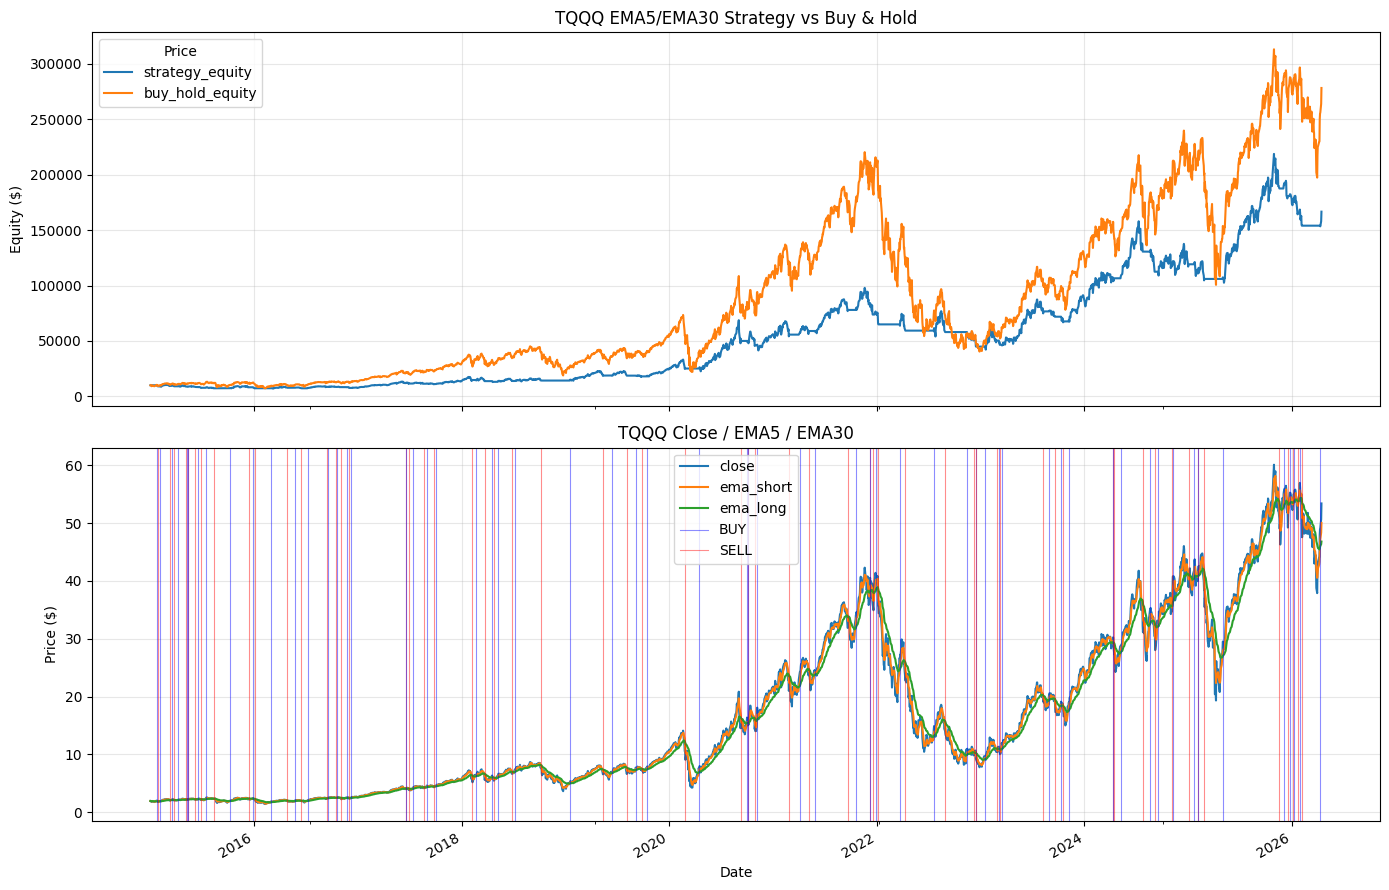

In [69]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

bt[["strategy_equity", "buy_hold_equity"]].plot(ax=axes[0])
axes[0].set_title(f"{SYMBOL} EMA5/EMA30 Strategy vs Buy & Hold")
axes[0].set_ylabel("Equity ($)")
axes[0].grid(True, alpha=0.3)

bt[["close", "ema_short", "ema_long"]].plot(ax=axes[1])

# 用细竖线标记每次实际交易日：蓝色是买入，红色是卖出。
# trade_date 是信号生成后的下一交易日，也就是按开盘价成交的日期。
buy_label_added = False
sell_label_added = False
for row in trades.itertuples(index=False):
    if row.action == "BUY":
        axes[1].axvline(
            row.trade_date,
            color="blue",
            linewidth=0.8,
            alpha=0.45,
            label="BUY" if not buy_label_added else None,
        )
        buy_label_added = True
    elif row.action == "SELL":
        axes[1].axvline(
            row.trade_date,
            color="red",
            linewidth=0.8,
            alpha=0.45,
            label="SELL" if not sell_label_added else None,
        )
        sell_label_added = True

axes[1].set_title(f"{SYMBOL} Close / EMA5 / EMA30")
axes[1].set_ylabel("Price ($)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## 对比：收盘价成交 vs 次日开盘成交，并导出 CSV

这里会用同一套 EMA5/EMA30 信号同时模拟两种执行方式：

- `close_after_signal`：第 t 日收盘确认信号后，按第 t 日收盘价附近成交，接近盘后立即交易的假设。
- `next_open`：第 t 日收盘确认信号后，按第 t+1 日开盘价成交。

会导出两个 CSV：

- `outputs/tqqq_ema_strategy_summary.csv`：各执行方式的年化收益、胜率、赔率、最大回撤等汇总。
- `outputs/tqqq_ema_trade_ledger.csv`：每次 BUY/SELL 的交易记录、成交价、手续费、交易后资产。


In [70]:
from pathlib import Path

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


def build_ema_base(data: pd.DataFrame) -> pd.DataFrame:
    base = data.copy()
    base["ema_short"] = base["close"].ewm(span=SHORT_WINDOW, adjust=False).mean()
    base["ema_long"] = base["close"].ewm(span=LONG_WINDOW, adjust=False).mean()
    base["signal"] = (base["ema_short"] > base["ema_long"]).astype(int)
    base["daily_return"] = base["close"].pct_change().fillna(0)
    return base


def simulate_execution(base: pd.DataFrame, execution_mode: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    sim = base.copy()
    if execution_mode == "next_open":
        sim["target_position"] = sim["signal"].shift(1).fillna(0).astype(int)
        price_col = "open"
        timing_note = "收盘确认后，下一交易日开盘成交"
    elif execution_mode == "close_after_signal":
        sim["target_position"] = sim["signal"].astype(int)
        price_col = "close"
        timing_note = "收盘确认后，按当日收盘价附近成交"
    else:
        raise ValueError(f"Unsupported execution_mode: {execution_mode}")

    sim["trade_signal"] = sim["target_position"].diff().fillna(sim["target_position"]).astype(int)

    cash = INITIAL_CAPITAL
    shares = 0.0
    rows = []
    equity_values = []
    position_values = []
    commission_values = []
    trade_price_values = []

    for row in sim.itertuples():
        trade_signal = int(row.trade_signal)
        trade_price = float(getattr(row, price_col))
        close_price = float(row.close)
        commission = 0.0
        executed_price = None
        action = None
        cash_before = cash
        shares_before = shares

        if trade_signal == 1 and shares == 0:
            action = "BUY"
            commission = COMMISSION_PER_TRADE
            investable_cash = max(cash - commission, 0)
            shares = investable_cash / trade_price
            cash = 0.0
            executed_price = trade_price
        elif trade_signal == -1 and shares > 0:
            action = "SELL"
            commission = COMMISSION_PER_TRADE
            cash = shares * trade_price - commission
            shares = 0.0
            executed_price = trade_price

        equity = cash + shares * close_price
        equity_values.append(equity)
        position_values.append(1 if shares > 0 else 0)
        commission_values.append(commission)
        trade_price_values.append(executed_price)

        if action:
            rows.append(
                {
                    "execution_mode": execution_mode,
                    "timing_note": timing_note,
                    "trade_date": row.Index,
                    "action": action,
                    "execution_price_type": price_col,
                    "execution_price": executed_price,
                    "close_for_valuation": close_price,
                    "ema_short": row.ema_short,
                    "ema_long": row.ema_long,
                    "commission": commission,
                    "cash_before": cash_before,
                    "shares_before": shares_before,
                    "cash_after": cash,
                    "shares_after": shares,
                    "equity_after": equity,
                }
            )

    sim["position"] = position_values
    sim["commission"] = commission_values
    sim["trade_price"] = trade_price_values
    sim["strategy_equity"] = equity_values
    sim["strategy_return"] = sim["strategy_equity"].pct_change().fillna(0)
    sim["buy_hold_equity"] = INITIAL_CAPITAL * (sim["close"] / sim["close"].iloc[0])

    trade_ledger = pd.DataFrame(rows)
    closed = build_closed_trades(trade_ledger)
    summary_row = build_summary_row(sim, trade_ledger, closed, execution_mode, timing_note)
    return sim, trade_ledger, summary_row


def build_closed_trades(trade_ledger: pd.DataFrame) -> pd.DataFrame:
    completed = []
    entry = None
    for row in trade_ledger.itertuples(index=False):
        if row.action == "BUY":
            entry = row
        elif row.action == "SELL" and entry is not None:
            completed.append(
                {
                    "execution_mode": row.execution_mode,
                    "entry_date": entry.trade_date,
                    "entry_price": entry.execution_price,
                    "entry_equity_after": entry.equity_after,
                    "exit_date": row.trade_date,
                    "exit_price": row.execution_price,
                    "exit_equity_after": row.equity_after,
                    "gross_return": row.execution_price / entry.execution_price - 1,
                    "net_return_after_fee": row.equity_after / entry.equity_after - 1,
                    "commission": entry.commission + row.commission,
                }
            )
            entry = None
    return pd.DataFrame(completed)


def profit_factor(returns: pd.Series) -> float:
    wins = returns[returns > 0].sum()
    losses = returns[returns < 0].sum()
    if losses == 0:
        return float("inf") if wins > 0 else 0.0
    return float(wins / abs(losses))


def build_summary_row(sim: pd.DataFrame, trade_ledger: pd.DataFrame, closed: pd.DataFrame, execution_mode: str, timing_note: str) -> pd.DataFrame:
    final_equity = sim["strategy_equity"].iloc[-1]
    closed_count = len(closed)
    wins = int((closed["net_return_after_fee"] > 0).sum()) if closed_count else 0
    losses = int((closed["net_return_after_fee"] <= 0).sum()) if closed_count else 0
    win_rate = wins / closed_count if closed_count else 0.0
    avg_win = closed.loc[closed["net_return_after_fee"] > 0, "net_return_after_fee"].mean() if wins else 0.0
    avg_loss = closed.loc[closed["net_return_after_fee"] <= 0, "net_return_after_fee"].mean() if losses else 0.0
    payoff_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else float("inf") if avg_win > 0 else 0.0

    return pd.DataFrame(
        [
            {
                "execution_mode": execution_mode,
                "timing_note": timing_note,
                "start_date": sim.index[0].date().isoformat(),
                "end_date": sim.index[-1].date().isoformat(),
                "initial_capital": INITIAL_CAPITAL,
                "final_equity": final_equity,
                "total_return": final_equity / INITIAL_CAPITAL - 1,
                "annualized_return": annualized_return(sim["strategy_equity"]),
                "max_drawdown": max_drawdown(sim["strategy_equity"]),
                "annualized_volatility": annualized_volatility(sim["strategy_return"]),
                "trade_events": len(trade_ledger),
                "closed_trades": closed_count,
                "wins": wins,
                "losses": losses,
                "win_rate": win_rate,
                "avg_win": avg_win,
                "avg_loss": avg_loss,
                "payoff_ratio": payoff_ratio,
                "profit_factor": profit_factor(closed["net_return_after_fee"]) if closed_count else 0.0,
                "total_commission": trade_ledger["commission"].sum() if not trade_ledger.empty else 0.0,
            }
        ]
    )


base = build_ema_base(df)
results = {}
ledgers = []
summary_rows = []
closed_rows = []

for mode in ["close_after_signal", "next_open"]:
    sim_df, ledger_df, summary_df = simulate_execution(base, mode)
    results[mode] = sim_df
    ledgers.append(ledger_df)
    summary_rows.append(summary_df)
    closed_rows.append(build_closed_trades(ledger_df))

strategy_summary = pd.concat(summary_rows, ignore_index=True)
trade_ledger = pd.concat(ledgers, ignore_index=True)
closed_trade_summary = pd.concat(closed_rows, ignore_index=True)

strategy_summary.to_csv(OUTPUT_DIR / "tqqq_ema_strategy_summary.csv", index=False)
trade_ledger.to_csv(OUTPUT_DIR / "tqqq_ema_trade_ledger.csv", index=False)
closed_trade_summary.to_csv(OUTPUT_DIR / "tqqq_ema_closed_trades.csv", index=False)

summary_display = strategy_summary.copy()
for col in ["final_equity", "initial_capital", "total_commission"]:
    summary_display[col] = summary_display[col].map(lambda x: f"${x:,.2f}")
for col in ["total_return", "annualized_return", "max_drawdown", "annualized_volatility", "win_rate", "avg_win", "avg_loss"]:
    summary_display[col] = summary_display[col].map(lambda x: f"{x:.2%}")
summary_display[[
    "execution_mode", "final_equity", "total_return", "annualized_return", "max_drawdown",
    "closed_trades", "wins", "losses", "win_rate", "payoff_ratio", "profit_factor", "total_commission"
]]


,execution_mode,final_equity,total_return,annualized_return,max_drawdown,closed_trades,wins,losses,win_rate,payoff_ratio,profit_factor,total_commission
0,close_after_signal,"$178,854.19",1688.54%,29.13%,-49.58%,60,24,36,40.00%,4.2993,2.8662,$119.79
1,next_open,"$166,693.61",1566.94%,28.33%,-56.93%,60,24,36,40.00%,4.0532,2.7021,$119.79


In [71]:
print("已导出：")
print(OUTPUT_DIR / "tqqq_ema_strategy_summary.csv")
print(OUTPUT_DIR / "tqqq_ema_trade_ledger.csv")
print(OUTPUT_DIR / "tqqq_ema_closed_trades.csv")

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 240):
    display(trade_ledger.tail(30))


已导出：
outputs/tqqq_ema_strategy_summary.csv
outputs/tqqq_ema_trade_ledger.csv
outputs/tqqq_ema_closed_trades.csv


,execution_mode,timing_note,trade_date,action,execution_price_type,execution_price,close_for_valuation,ema_short,ema_long,commission,cash_before,shares_before,cash_after,shares_after,equity_after
212,next_open,收盘确认后，下一交易日开盘成交,2023-09-19,SELL,open,19.0890,19.1810,19.4612,19.6155,0.9900,0.0000,"3,765.9457","71,887.0511",0.0000,"71,887.0511"
213,next_open,收盘确认后，下一交易日开盘成交,2023-10-12,BUY,open,19.1854,18.8986,18.6158,18.4436,0.9900,"71,887.0511",0.0000,0.0000,"3,746.9195","70,811.5036"
214,next_open,收盘确认后，下一交易日开盘成交,2023-10-19,SELL,open,18.0577,17.3529,18.0096,18.3517,0.9900,0.0000,"3,746.9195","67,659.6831",0.0000,"67,659.6831"
215,next_open,收盘确认后，下一交易日开盘成交,2023-11-07,BUY,open,18.6410,18.9958,18.0776,17.5731,0.9900,"67,659.6831",0.0000,0.0000,"3,629.5698","68,946.5960"
216,next_open,收盘确认后，下一交易日开盘成交,2024-04-11,SELL,open,29.2071,30.2312,29.5868,29.3798,0.9900,0.0000,"3,629.5698","106,008.3364",0.0000,"106,008.3364"
217,next_open,收盘确认后，下一交易日开盘成交,2024-04-12,BUY,open,29.3394,28.7711,29.3149,29.3405,0.9900,"106,008.3364",0.0000,0.0000,"3,613.1365","103,953.7642"
218,next_open,收盘确认后，下一交易日开盘成交,2024-04-15,SELL,open,29.4962,27.3256,28.6518,29.2106,0.9900,0.0000,"3,613.1365","106,572.8586",0.0000,"106,572.8586"
219,next_open,收盘确认后，下一交易日开盘成交,2024-05-08,BUY,open,28.1733,28.6388,28.0715,27.6446,0.9900,"106,572.8586",0.0000,0.0000,"3,782.7267","108,332.6227"
220,next_open,收盘确认后，下一交易日开盘成交,2024-07-24,SELL,open,34.5422,32.1912,35.0737,36.3907,0.9900,0.0000,"3,782.7267","130,662.8140",0.0000,"130,662.8140"
221,next_open,收盘确认后，下一交易日开盘成交,2024-08-20,BUY,open,34.8718,34.8521,33.6848,32.6908,0.9900,"130,662.8140",0.0000,0.0000,"3,746.9238","130,588.1062"
